# Real-World Case Study: Option Valuation Differences Across Asset Classes

## Imports and setup

In [1]:
# Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
# Setup
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Shared pricing functions

We use the minimum set of functions needed for a clean cross-asset comparison:

- **Black-Scholes-Merton with dividends** for equities  
- **Garman-Kohlhagen** for FX  
- **Black-76** for options on futures and forward-style underlyings  
- **Black caplet-style formula** for a simple interest-rate option example


In [3]:
def mb_bsm_dividend(S, K, T, r, q, sigma, option_type="call"):
    if T <= 0:
        return max(S - K, 0.0) if option_type == "call" else max(K - S, 0.0)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == "call":
        return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)

def mb_bsm_dividend_delta(S, K, T, r, q, sigma, option_type="call"):
    if T <= 0:
        if S > K:
            return 1.0 if option_type == "call" else 0.0
        if S < K:
            return 0.0 if option_type == "call" else -1.0
        return 0.5 if option_type == "call" else -0.5

    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    if option_type == "call":
        return np.exp(-q * T) * norm.cdf(d1)
    return np.exp(-q * T) * (norm.cdf(d1) - 1)

def mb_garman_kohlhagen(S, K, T, rd, rf, sigma, option_type="call"):
    if T <= 0:
        return max(S - K, 0.0) if option_type == "call" else max(K - S, 0.0)
    d1 = (np.log(S / K) + (rd - rf + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == "call":
        return S * np.exp(-rf * T) * norm.cdf(d1) - K * np.exp(-rd * T) * norm.cdf(d2)
    return K * np.exp(-rd * T) * norm.cdf(-d2) - S * np.exp(-rf * T) * norm.cdf(-d1)

def mb_black76(F, K, T, r, sigma, option_type="call"):
    if T <= 0:
        intrinsic = max(F - K, 0.0) if option_type == "call" else max(K - F, 0.0)
        return np.exp(-r * T) * intrinsic
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    df = np.exp(-r * T)
    if option_type == "call":
        return df * (F * norm.cdf(d1) - K * norm.cdf(d2))
    return df * (K * norm.cdf(-d2) - F * norm.cdf(-d1))

def mb_black76_delta(F, K, T, r, sigma, option_type="call"):
    if T <= 0:
        if F > K:
            return 1.0 if option_type == "call" else 0.0
        if F < K:
            return 0.0 if option_type == "call" else -1.0
        return 0.5 if option_type == "call" else -0.5

    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    df = np.exp(-r * T)
    if option_type == "call":
        return df * norm.cdf(d1)
    return -df * norm.cdf(-d1)

def mb_caplet_black(notional, accrual, F, K, T, df, sigma):
    if T <= 0:
        return notional * accrual * df * max(F - K, 0.0)
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return notional * accrual * df * (F * norm.cdf(d1) - K * norm.cdf(d2))


## Case Study 1 - Equity option (AAPL)

In [4]:
eq = {
    "asset_class": "Equity",
    "instrument": "AAPL call",
    "S": 175.16,
    "K": 180.0,
    "T": 0.50,
    "r": 0.0500,
    "q": 0.0055,
    "sigma": 0.24
}

eq_price = mb_bsm_dividend(eq["S"], eq["K"], eq["T"], eq["r"], eq["q"], eq["sigma"], "call")
eq_delta = mb_bsm_dividend_delta(eq["S"], eq["K"], eq["T"], eq["r"], eq["q"], eq["sigma"], "call")

pd.DataFrame([{
    "Instrument": eq["instrument"],
    "Spot": eq["S"],
    "Strike": eq["K"],
    "Maturity (yrs)": eq["T"],
    "Rate": eq["r"],
    "Dividend Yield": eq["q"],
    "Volatility": eq["sigma"],
    "Call Price": eq_price,
    "Delta": eq_delta
}])

,Instrument,Spot,Strike,Maturity (yrs),Rate,Dividend Yield,Volatility,Call Price,Delta
0,AAPL call,175.1600,180.0000,0.5000,0.0500,0.0055,0.2400,11.4085,0.5206


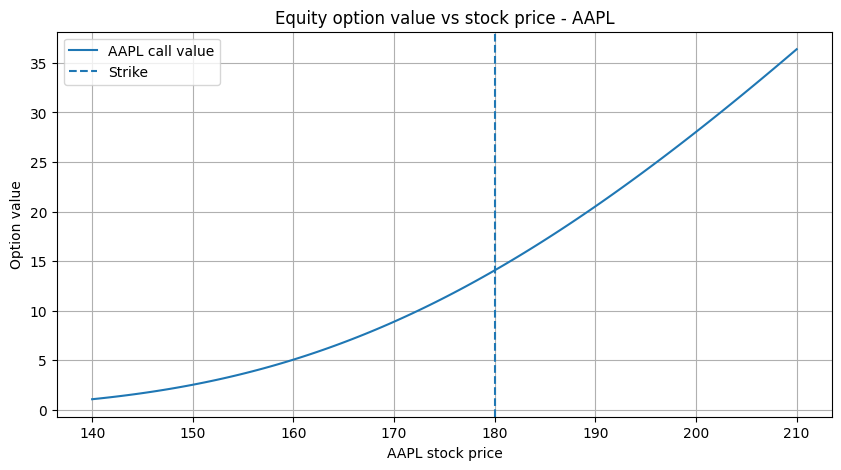

In [5]:
eq_spot_grid = np.linspace(140, 210, 120)
eq_price_grid = [
    mb_bsm_dividend(s, eq["K"], eq["T"], eq["r"], eq["q"], eq["sigma"], "call")
    for s in eq_spot_grid
]

plt.plot(eq_spot_grid, eq_price_grid, label="AAPL call value")
plt.axvline(eq["K"], linestyle="--", label="Strike")
plt.title("Equity option value vs stock price - AAPL")
plt.xlabel("AAPL stock price")
plt.ylabel("Option value")
plt.legend()
plt.show()

## Case Study 2 - FX option (EUR/USD)

In [6]:
fx = {
    "asset_class": "FX",
    "instrument": "EUR/USD call",
    "S": 1.0800,
    "K": 1.1000,
    "T": 0.25,
    "rd": 0.0525,
    "rf": 0.0300,
    "sigma": 0.095
}

fx_price = mb_garman_kohlhagen(fx["S"], fx["K"], fx["T"], fx["rd"], fx["rf"], fx["sigma"], "call")

pd.DataFrame([{
    "Instrument": fx["instrument"],
    "Spot": fx["S"],
    "Strike": fx["K"],
    "Maturity (yrs)": fx["T"],
    "Domestic Rate": fx["rd"],
    "Foreign Rate": fx["rf"],
    "Volatility": fx["sigma"],
    "Call Price": fx_price
}])

,Instrument,Spot,Strike,Maturity (yrs),Domestic Rate,Foreign Rate,Volatility,Call Price
0,EUR/USD call,1.0800,1.1000,0.2500,0.0525,0.0300,0.0950,0.0143


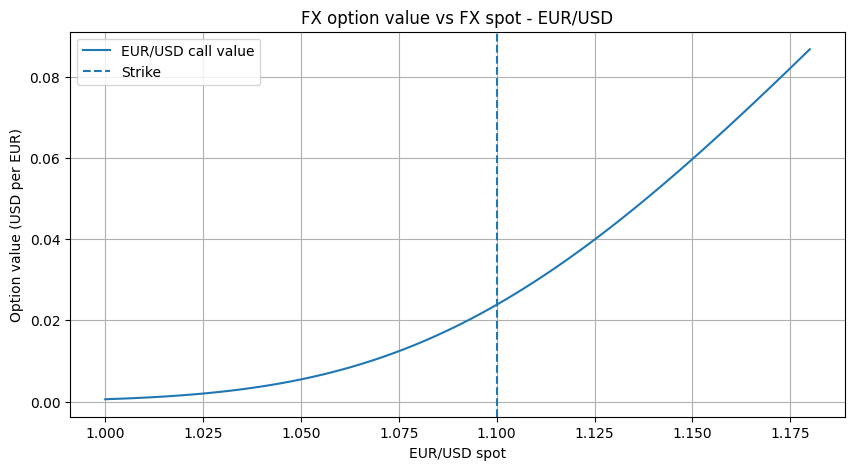

In [7]:
fx_spot_grid = np.linspace(1.00, 1.18, 120)
fx_price_grid = [
    mb_garman_kohlhagen(s, fx["K"], fx["T"], fx["rd"], fx["rf"], fx["sigma"], "call")
    for s in fx_spot_grid
]

plt.plot(fx_spot_grid, fx_price_grid, label="EUR/USD call value")
plt.axvline(fx["K"], linestyle="--", label="Strike")
plt.title("FX option value vs FX spot - EUR/USD")
plt.xlabel("EUR/USD spot")
plt.ylabel("Option value (USD per EUR)")
plt.legend()
plt.show()

## Case Study 3 - Commodity option (WTI crude oil futures option)

In [8]:
cmdty = {
    "asset_class": "Commodity",
    "instrument": "WTI futures call",
    "F": 78.0,
    "K": 80.0,
    "T": 0.50,
    "r": 0.0500,
    "sigma": 0.30
}

cmdty_price = mb_black76(cmdty["F"], cmdty["K"], cmdty["T"], cmdty["r"], cmdty["sigma"], "call")
cmdty_delta = mb_black76_delta(cmdty["F"], cmdty["K"], cmdty["T"], cmdty["r"], cmdty["sigma"], "call")

pd.DataFrame([{
    "Instrument": cmdty["instrument"],
    "Futures Price": cmdty["F"],
    "Strike": cmdty["K"],
    "Maturity (yrs)": cmdty["T"],
    "Rate": cmdty["r"],
    "Volatility": cmdty["sigma"],
    "Call Price": cmdty_price,
    "Delta vs Futures": cmdty_delta
}])

,Instrument,Futures Price,Strike,Maturity (yrs),Rate,Volatility,Call Price,Delta vs Futures
0,WTI futures call,78.0000,80.0000,0.5000,0.0500,0.3000,5.5792,0.4825


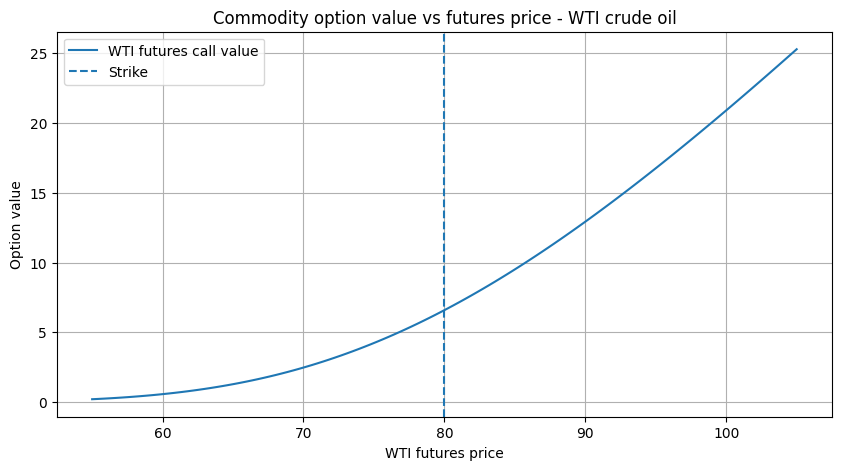

In [9]:
cmdty_f_grid = np.linspace(55, 105, 120)
cmdty_price_grid = [
    mb_black76(f, cmdty["K"], cmdty["T"], cmdty["r"], cmdty["sigma"], "call")
    for f in cmdty_f_grid
]

plt.plot(cmdty_f_grid, cmdty_price_grid, label="WTI futures call value")
plt.axvline(cmdty["K"], linestyle="--", label="Strike")
plt.title("Commodity option value vs futures price - WTI crude oil")
plt.xlabel("WTI futures price")
plt.ylabel("Option value")
plt.legend()
plt.show()

## Case Study 4 - Interest-rate option (SOFR caplet-style example)

In [10]:
ir = {
    "asset_class": "Interest Rate",
    "instrument": "SOFR caplet",
    "notional": 10_000_000,
    "accrual": 0.25,
    "F": 0.0435,
    "K": 0.0400,
    "T": 0.50,
    "df": 0.975,
    "sigma": 0.22
}

ir_price = mb_caplet_black(
    ir["notional"], ir["accrual"], ir["F"], ir["K"], ir["T"], ir["df"], ir["sigma"]
)

pd.DataFrame([{
    "Instrument": ir["instrument"],
    "Notional": ir["notional"],
    "Forward Rate": ir["F"],
    "Strike": ir["K"],
    "Accrual": ir["accrual"],
    "Expiry (yrs)": ir["T"],
    "Discount Factor": ir["df"],
    "Volatility": ir["sigma"],
    "Caplet Price": ir_price
}])

,Instrument,Notional,Forward Rate,Strike,Accrual,Expiry (yrs),Discount Factor,Volatility,Caplet Price
0,SOFR caplet,10000000,0.0435,0.0400,0.2500,0.5000,0.9750,0.2200,"11,468.0816"


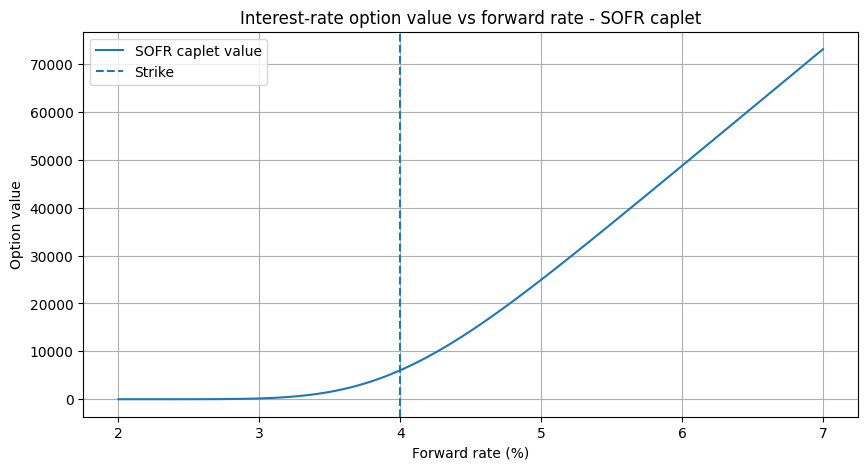

In [11]:
ir_f_grid = np.linspace(0.020, 0.070, 120)
ir_price_grid = [
    mb_caplet_black(ir["notional"], ir["accrual"], f, ir["K"], ir["T"], ir["df"], ir["sigma"])
    for f in ir_f_grid
]

plt.plot(ir_f_grid * 100, ir_price_grid, label="SOFR caplet value")
plt.axvline(ir["K"] * 100, linestyle="--", label="Strike")
plt.title("Interest-rate option value vs forward rate - SOFR caplet")
plt.xlabel("Forward rate (%)")
plt.ylabel("Option value")
plt.legend()
plt.show()

## Cross-asset comparison

In [12]:
comparison_rows = []

# Equity
eq_vol_up = mb_bsm_dividend(eq["S"], eq["K"], eq["T"], eq["r"], eq["q"], eq["sigma"] + 0.02, "call")
eq_under_up = mb_bsm_dividend(eq["S"] * 1.05, eq["K"], eq["T"], eq["r"], eq["q"], eq["sigma"], "call")
comparison_rows.append({
    "Asset Class": "Equity",
    "Instrument": eq["instrument"],
    "Base Price": eq_price,
    "Vol Bump Price": eq_vol_up,
    "Underlying Bump Price": eq_under_up,
    "Main Driver": "Spot + dividends",
    "Underlying Bump": "+5% stock spot"
})

# FX
fx_vol_up = mb_garman_kohlhagen(fx["S"], fx["K"], fx["T"], fx["rd"], fx["rf"], fx["sigma"] + 0.02, "call")
fx_under_up = mb_garman_kohlhagen(fx["S"] * 1.02, fx["K"], fx["T"], fx["rd"], fx["rf"], fx["sigma"], "call")
comparison_rows.append({
    "Asset Class": "FX",
    "Instrument": fx["instrument"],
    "Base Price": fx_price,
    "Vol Bump Price": fx_vol_up,
    "Underlying Bump Price": fx_under_up,
    "Main Driver": "Spot + domestic/foreign rates",
    "Underlying Bump": "+2% FX spot"
})

# Commodity
cmdty_vol_up = mb_black76(cmdty["F"], cmdty["K"], cmdty["T"], cmdty["r"], cmdty["sigma"] + 0.02, "call")
cmdty_under_up = mb_black76(cmdty["F"] * 1.05, cmdty["K"], cmdty["T"], cmdty["r"], cmdty["sigma"], "call")
comparison_rows.append({
    "Asset Class": "Commodity",
    "Instrument": cmdty["instrument"],
    "Base Price": cmdty_price,
    "Vol Bump Price": cmdty_vol_up,
    "Underlying Bump Price": cmdty_under_up,
    "Main Driver": "Futures curve",
    "Underlying Bump": "+5% futures price"
})

# Interest rate
ir_vol_up = mb_caplet_black(ir["notional"], ir["accrual"], ir["F"], ir["K"], ir["T"], ir["df"], ir["sigma"] + 0.02)
ir_under_up = mb_caplet_black(ir["notional"], ir["accrual"], ir["F"] + 0.0025, ir["K"], ir["T"], ir["df"], ir["sigma"])
comparison_rows.append({
    "Asset Class": "Interest Rate",
    "Instrument": ir["instrument"],
    "Base Price": ir_price,
    "Vol Bump Price": ir_vol_up,
    "Underlying Bump Price": ir_under_up,
    "Main Driver": "Forward rate + accrual + discounting",
    "Underlying Bump": "+25 bp forward-rate shift"
})

comparison_df = pd.DataFrame(comparison_rows)

# Absolute sensitivities
comparison_df["Vol Sensitivity Abs"] = comparison_df["Vol Bump Price"] - comparison_df["Base Price"]
comparison_df["Underlying Sensitivity Abs"] = comparison_df["Underlying Bump Price"] - comparison_df["Base Price"]

# Normalized sensitivities (% of base price)
comparison_df["Vol Sensitivity %"] = 100 * comparison_df["Vol Sensitivity Abs"] / comparison_df["Base Price"]
comparison_df["Underlying Sensitivity %"] = 100 * comparison_df["Underlying Sensitivity Abs"] / comparison_df["Base Price"]

comparison_df

,Asset Class,Instrument,Base Price,Vol Bump Price,Underlying Bump Price,Main Driver,Underlying Bump,Vol Sensitivity Abs,Underlying Sensitivity Abs,Vol Sensitivity %,Underlying Sensitivity %
0,Equity,AAPL call,11.4085,12.3922,16.4662,Spot + dividends,+5% stock spot,0.9837,5.0578,8.6229,44.3337
1,FX,EUR/USD call,0.0143,0.0185,0.0247,Spot + domestic/foreign rates,+2% FX spot,0.0042,0.0104,29.1933,72.8495
2,Commodity,WTI futures call,5.5792,6.0084,7.6362,Futures curve,+5% futures price,0.4292,2.0570,7.6927,36.8694
3,Interest Rate,SOFR caplet,"11,468.0816","11,968.5111","16,260.2299",Forward rate + accrual + discounting,+25 bp forward-rate shift,500.4295,"4,792.1483",4.3637,41.7868


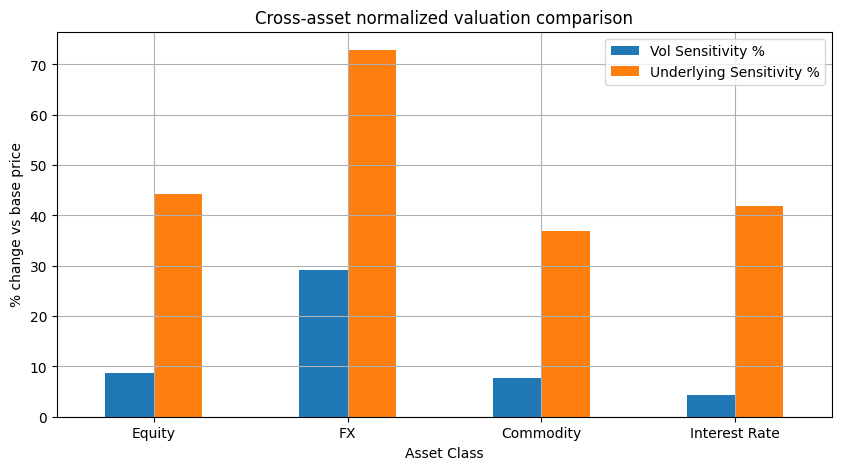

In [13]:
plot_df = comparison_df.set_index("Asset Class")[["Vol Sensitivity %", "Underlying Sensitivity %"]]
plot_df.plot(kind="bar")
plt.title("Cross-asset normalized valuation comparison")
plt.ylabel("% change vs base price")
plt.xticks(rotation=0)
plt.show()